In [1]:
import itertools
import numpy as np

def is_complementary(seq1, seq2):
    """Check if two sequences satisfy Watson-Crick complementarity with at least 4 mismatches."""
    mapping = np.array([3, 2, 1, 0])  # Complement mapping: A<->T (0<->3), C<->G (1<->2)
    seq1_reversed = np.flip(seq1)  # Reverse seq1
    seq2_complement = mapping[seq2]  # Map seq2 to its complement
    mismatches = np.sum(seq1_reversed != seq2_complement)
    return mismatches >= 4  # Complementarity requires at least 4 mismatches

def generate_all_valid_dna_words(word_length):
    """Generate all valid DNA words with GC weight 4 and Hamming distance >= 4 to reverse WC complement."""
    if word_length % 2 != 0:
        raise ValueError("Word length must be an even number for the 50% GC constraint.")
    
    # Map characters to integers
    char_to_int = {'A': 0, 'C': 1, 'G': 2, 'T': 3}
    int_to_char = {v: k for k, v in char_to_int.items()}
    
    # Generate all possible combinations of DNA sequences
    possible_combinations = itertools.product(range(4), repeat=word_length)
    
    valid_words = []
    for word in possible_combinations:
        word = np.array(word)
        
        # Check GC content constraint
        gc_count = np.sum((word == 1) | (word == 2))  # C and G have indices 1 and 2
        if gc_count != word_length // 2:
            continue
        
        # Check Hamming distance constraint to reverse Watson-Crick complement
        if not is_complementary(word, word):
            continue
        
        valid_words.append(tuple(word))
    
    valid_words.sort()  # Sort the tuples
    
    word_dict = {
        'capacity': len(valid_words),
        'items': valid_words
    }
    
    return word_dict

# Generate the dictionary
word_length = 8  # Word length (e.g., 4, 6, 8)
dna_data = generate_all_valid_dna_words(word_length)

# # Print the capacity and a few items for verification
# print("Capacity:", dna_data['capacity'])
# print("Sample Items:")
# for word in dna_data['items'][:10]:  # Print the first 10 valid words
#     print(''.join(['ACGT'[x] for x in word]))  # Convert numeric representation back to DNA characters


In [ ]:
def read_output(filepath, number, start=1):

  A=[]
  for n in range(start,start+number):
    file_path = f"{filepath}_{n}.txt"

    # file_path = f"results_online/output_{n}.txt"

    with open(file_path, "r") as file:
        binary_values = [int(line.strip()) for line in file]

    if len(dna_data['items']) != len(binary_values):
        raise ValueError(f"Length mismatch: A has {len(dna_data['items'])} items, but binary_values has {len(binary_values)} entries.")

    subset = [a for a, b in zip(dna_data['items'], binary_values) if b == 1]
    subset = [tuple(int(x) for x in item) for item in subset]
    if len(subset) > 136:
       print(f"found subset {len(subset)}!!")
    A.append(subset)

  A_136 = [t for t in A if len(t) >= 136]

  return A_136

start=1
numbers=[510,510]
file_paths = ["results8/output_8", "results8_online/output"]
A=[]
for idx, file_path in enumerate(file_paths): 
  A.extend(read_output(file_path, numbers[idx]))

  # Extract tuples of length 136

  # Output the result
  print("Filtered Tuples:", A)
  print("Number of tuples with length 136:", len(A))

for i, tuple_list in enumerate(A):  
    # Calculate the sum of all 0s, 1s, 2s, and 3s across all tuples
    counts = {0: 0, 1: 0, 2: 0, 3: 0}
    for tup in tuple_list:
        for value in tup:
            counts[value] += 1
    
    # Calculate the minimal sum of tuple elements and the corresponding tuple
    min_sum = float('inf')  # Start with infinity for comparison
    min_tuple = None
    tuples_with_sum_4 = []  # Store tuples with sum 4
    for tup in tuple_list:
        current_sum = sum(tup)
        if current_sum == 4:
            tuples_with_sum_4.append(tup)  # Collect tuples with sum 4
        if current_sum < min_sum:
            min_sum = current_sum
            min_tuple = tup

    # Output results for the current list
    print(f"List {i + 1}:")
    print(f"  Sum of all occurrences: 0s={counts[0]}, 1s={counts[1]}, 2s={counts[2]}, 3s={counts[3]}")
    print(f"  Minimal sum: {min_sum}, Corresponding tuple: {min_tuple}")
    
    if min_sum == 4:
        print(f"  Tuples with sum=4: {tuples_with_sum_4}")  # Print tuples with sum 4
    
    print("-" * 50)


# load from file, this is an (128, 8) array with elements 0 .. 3
funsearch = np.load("funsearch_tuple8.npy", allow_pickle=True)


Filtered Tuples: [[(0, 1, 2, 3, 1, 3, 2, 3), (0, 1, 3, 1, 3, 2, 2, 3), (0, 2, 2, 0, 0, 2, 1, 3), (0, 2, 3, 0, 1, 1, 2, 3), (0, 2, 3, 2, 2, 3, 1, 3), (0, 3, 1, 1, 1, 2, 3, 3), (0, 3, 2, 2, 2, 1, 3, 3), (1, 0, 0, 2, 2, 0, 1, 3), (1, 0, 1, 0, 0, 1, 1, 3), (1, 0, 2, 0, 0, 2, 3, 2), (1, 0, 2, 3, 3, 2, 1, 3), (1, 0, 3, 0, 2, 2, 2, 3), (1, 0, 3, 1, 1, 3, 1, 3), (1, 0, 3, 2, 2, 3, 3, 2), (1, 1, 0, 0, 1, 1, 3, 3), (1, 1, 1, 2, 0, 0, 0, 3), (1, 1, 2, 1, 0, 3, 3, 3), (1, 1, 3, 3, 1, 2, 0, 3), (1, 2, 0, 2, 0, 2, 3, 3), (1, 2, 0, 3, 0, 0, 2, 2), (1, 2, 0, 3, 2, 1, 0, 3), (1, 2, 1, 3, 1, 3, 3, 3), (1, 2, 2, 0, 2, 0, 3, 3), (1, 2, 2, 2, 3, 3, 0, 3), (1, 2, 3, 0, 3, 3, 2, 2), (1, 2, 3, 1, 3, 1, 3, 3), (1, 3, 0, 1, 2, 3, 2, 3), (1, 3, 1, 1, 3, 0, 1, 3), (1, 3, 1, 3, 0, 2, 2, 3), (1, 3, 2, 0, 3, 1, 2, 3), (1, 3, 2, 2, 3, 0, 3, 2), (1, 3, 2, 3, 1, 3, 0, 2), (1, 3, 3, 1, 3, 2, 0, 2), (1, 3, 3, 2, 1, 0, 2, 3), (2, 0, 0, 1, 0, 2, 2, 3), (2, 0, 0, 2, 1, 3, 0, 2), (2, 0, 1, 0, 1, 3, 2, 3), (2, 0, 1, 0, 3, 2, 

In [3]:
import numpy as np

# Load the funsearch array (128, 8)
funsearch = np.load("funsearch_tuple8.npy", allow_pickle=True)

# Convert funsearch to a set of 8-tuples
funsearch_set = {tuple(row) for row in funsearch}

# Function to calculate intersection cardinality
def calculate_intersection_cardinality(array_136, funsearch_set):
    # Convert array_136 to a set of tuples
    array_136_set = {tuple(row) for row in array_136}
    # Calculate the intersection
    intersection = array_136_set.intersection(funsearch_set)
    return len(intersection)

# Find the array of length 136 with the most overlap
max_overlap = 0
best_array = None
for i, array_136 in enumerate(A):  # A contains the arrays of length 136
    overlap_score = calculate_intersection_cardinality(array_136, funsearch_set)
    print(f"List {i + 1}: Overlap score = {overlap_score}")
    
    if overlap_score > max_overlap:
        max_overlap = overlap_score
        best_array = array_136

# Output the array with the most overlap
print("Array with the most overlap:")
print(best_array)
print(f"Maximum overlap score: {max_overlap}")



List 1: Overlap score = 1
List 2: Overlap score = 1
List 3: Overlap score = 0
List 4: Overlap score = 1
List 5: Overlap score = 0
List 6: Overlap score = 1
List 7: Overlap score = 0
List 8: Overlap score = 0
List 9: Overlap score = 2
List 10: Overlap score = 0
List 11: Overlap score = 0
List 12: Overlap score = 1
List 13: Overlap score = 1
List 14: Overlap score = 2
List 15: Overlap score = 0
List 16: Overlap score = 0
List 17: Overlap score = 1
List 18: Overlap score = 0
List 19: Overlap score = 0
List 20: Overlap score = 0
List 21: Overlap score = 0
List 22: Overlap score = 0
List 23: Overlap score = 0
List 24: Overlap score = 0
List 25: Overlap score = 2
List 26: Overlap score = 0
List 27: Overlap score = 0
List 28: Overlap score = 0
List 29: Overlap score = 0
List 30: Overlap score = 0
List 31: Overlap score = 0
List 32: Overlap score = 2
List 33: Overlap score = 0
List 34: Overlap score = 0
List 35: Overlap score = 0
List 36: Overlap score = 0
List 37: Overlap score = 1
List 38: O

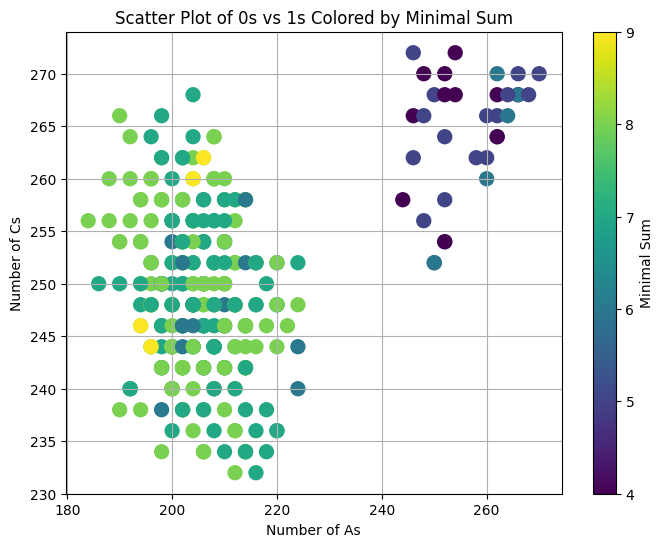

In [4]:
import matplotlib.pyplot as plt


# Initialize data for plotting
num_zeros = []
num_ones = []
minimal_sums = []

# Process each list of tuples
for tuple_list in A:
    # Count 0s and 1s in the current list
    counts = {0: 0, 1: 0, 2: 0, 3: 0}
    for tup in tuple_list:
        for value in tup:
            counts[value] += 1
    
    counts = sorted(counts.values())
    
    # Determine minimal sum in the current list
    min_sum = float('inf')
    for tup in tuple_list:
        current_sum = sum(tup)
        if current_sum < min_sum:
            min_sum = current_sum

    # Append data for plotting
    num_zeros.append(counts[0])
    num_ones.append(counts[1])
    minimal_sums.append(min_sum)

# Create scatter plot
plt.figure(figsize=(8, 6))
scatter = plt.scatter(num_zeros, num_ones, c=minimal_sums, cmap='viridis', s=100)
plt.colorbar(scatter, label='Minimal Sum')
plt.title('Scatter Plot of 0s vs 1s Colored by Minimal Sum')
plt.xlabel('Number of As')
plt.ylabel('Number of Cs')
# plt.legend(*scatter.legend_elements(), title="Minimal Sum")
plt.grid(True)
plt.show()





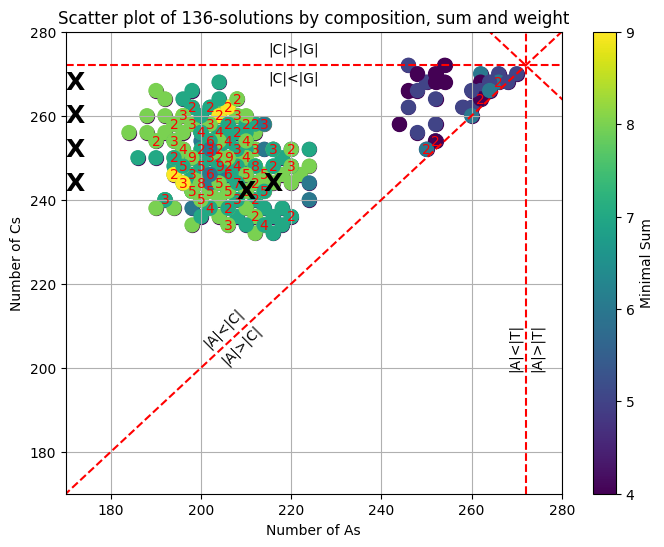

In [ ]:
import matplotlib.pyplot as plt
from collections import Counter

# Compute data points and their multiplicities
data_points = list(zip(num_zeros, num_ones))
multiplicities = Counter(data_points)

# Create scatter plot with multiplicities shown
plt.figure(figsize=(8, 6))

for (x, y), count in multiplicities.items():
    # Get the minimal sum corresponding to the data point
    idx = data_points.index((x, y))
    min_sum = minimal_sums[idx]
    
    # Scatter point
    plt.scatter(x, y, c=[min_sum], cmap='viridis', s=100, label=f"Min Sum={min_sum}" if count == 1 else None)
    
    # Annotate multiplicity if greater than 1
    if count > 1:
        plt.text(x, y, str(count), fontsize=10, color='red', ha='center', va='center')

# Add colorbar and labels
scatter = plt.scatter(num_zeros, num_ones, c=minimal_sums, cmap='viridis', s=100)
xmin=170
xmax=280
x = np.linspace(0, 544, 100)
plt.plot(x, x, color='red', linestyle='--')
plt.plot(x, 544-x, color='red', linestyle='--')

plt.title('Scatter plot of 136-solutions by composition, sum and weight')
plt.colorbar(scatter, label='Minimal Sum')

plt.xlabel('Number of As')
plt.ylabel('Number of Cs')
plt.axhline(272,color='red', linestyle='--')
plt.axvline(272,color='red', linestyle='--')
plt.text(215, 275, "|C|>|G|")
plt.text(215, 268, "|C|<|G|")
plt.text(200, 205, "|A|<|C|", rotation=45)
plt.text(204, 201, "|A|>|C|", rotation=45)
plt.text(273, 200, "|A|>|T|", rotation=90)
plt.text(268, 200, "|A|<|T|", rotation=90)

# result from 128-FunSearch solution, after adding +2 to A,C,T,G to get to 136
plt.text(172, 268, 'X', fontweight='bold', fontsize=18, ha='center', va='center')
plt.text(172, 260, 'X', fontweight='bold', fontsize=18, ha='center', va='center')
plt.text(172, 252, 'X', fontweight='bold', fontsize=18, ha='center', va='center')
plt.text(172, 244, 'X', fontweight='bold', fontsize=18, ha='center', va='center')
plt.text(216, 244, 'X', fontweight='bold', fontsize=18, ha='center', va='center')
plt.text(210, 242, 'X', fontweight='bold', fontsize=18, ha='center', va='center')
plt.xlim([xmin,xmax])
plt.ylim([xmin,xmax])
plt.grid(True)
plt.show()


In [23]:
import numpy as np

def is_complementary(seq1, seq2):
    """Check if two sequences satisfy Watson-Crick complementarity."""
    mapping = np.array([3, 2, 1, 0])  # Complement mapping: A<->T (0<->3), C<->G (1<->2)
    seq1_reversed = np.flip(seq1)  # Reverse seq1
    seq2_complement = mapping[seq2]  # Map seq2 to its complement
    mismatches = np.sum(seq1_reversed != seq2_complement)
    return mismatches >= 4  # Complementarity requires at least 4 mismatches

def check_constraints_debug(wordset):
    """Evaluate and report which constraints are not met."""
    wordset = np.array(wordset)  # Ensure input is an ndarray
    n = len(wordset)
    
    # Initialize masks
    mask_gc_content = np.array([
        (np.sum((word == 1) | (word == 2)) == 4)  # GC content check (4 G or C)
        for word in wordset
    ], dtype=bool)
    
    mask_diffs = np.ones(n, dtype=bool)  # Hamming distance mask
    mask_complementary = np.ones(n, dtype=bool)  # Complementarity mask

    # Hamming distance check
    for i in range(n):
        for j in range(i + 1, n):
            if np.sum(wordset[i] != wordset[j]) < 4:  # Hamming distance must be >= 4
                mask_diffs[i] = mask_diffs[j] = False

    # Complementarity check
    for i in range(n):
        for j in range(i + 1, n):
            if not is_complementary(wordset[i], wordset[j]):
                mask_complementary[i] = mask_complementary[j] = False

    # Combine all masks
    final_mask = mask_diffs & mask_complementary & mask_gc_content

    # Debug: Report unmet constraints
    unmet_constraints = []
    for idx, word in enumerate(wordset):
        reasons = []
        if not mask_gc_content[idx]:
            reasons.append("GC content")
        if not mask_diffs[idx]:
            reasons.append("Hamming distance")
        if not mask_complementary[idx]:
            reasons.append("Complementarity")
        if reasons:
            unmet_constraints.append((word, reasons))

    return {
        "final_mask": final_mask,
        "filtered_subset": wordset[final_mask],
        "unmet_constraints": unmet_constraints,
    }


results = check_constraints_debug(subset)

# Final filtered subset
print("Filtered Subset:", results["filtered_subset"])

# Report unmet constraints
print("\nUnmet Constraints:")
for word, reasons in results["unmet_constraints"]:
    print(f"Sequence {word} failed due to: {', '.join(reasons)}")


Filtered Subset: [[0 1 2 ... 3 2 3]
 [0 1 3 ... 2 2 3]
 [0 2 2 ... 2 1 3]
 ...
 [3 3 3 ... 1 2 2]
 [3 3 3 ... 2 2 1]
 [3 3 3 ... 3 1 2]]

Unmet Constraints:
